# 1. Импорт библиотек

Импортируем библиотеки для работы с данными, визуализации и непараметрических моделей: *numpy*, *pandas*, *matplotlib*, *seaborn*, *sklearn*.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.metrics import mean_absolute_error,r2_score

# 2. Загрузка и очистка данных

Загружаем *used_cars.csv* и приводим *price* и *milage* к числовому виду, убирая символы **$**, запятые и **mi.**. Строки с пропусками удаляем.

In [2]:
df = pd.read_csv(r"used_cars.csv")

df['price'] = pd.to_numeric(df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False), errors='coerce')
df['milage'] = pd.to_numeric(df['milage'].str.replace(' mi.', '', regex=False).str.replace(',', '', regex=False), errors='coerce')
df = df.dropna(subset=['price', 'milage'])

print(f"Размер таблицы: {df.shape[0]} автомобилей и {df.shape[1]} параметров")

accident_impact = df.groupby("accident")["price"].median()
print("\nМедианные цены ($) в зависимости от ДТП:\n", accident_impact)

df.head(3)

Размер таблицы: 4009 автомобилей и 12 параметров

Медианные цены ($) в зависимости от ДТП:
 accident
At least 1 accident or damage reported    20900.0
None reported                             35667.5
Name: price, dtype: float64


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,51000,E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,10300
1,Hyundai,Palisade SEL,2021,34742,Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,38005
2,Lexus,RX 350 RX 350,2022,22372,Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,54598


# 3. Влияние ДТП на цену

Смотрим среднюю цену в зависимости от наличия ДТП через *groupby* - так видно, насколько аварии снижают стоимость авто.

In [ ]:
brand_impact = df.groupby("brand")["price"].median().sort_values(ascending=False)
print("Топ-10 марок по средней цене:\n", brand_impact.head(10))

Топ-10 марок по медианной цене:
 brand
Bugatti        1950995.0
Rolls-Royce     399950.0
Lamborghini     258000.0
Ferrari         249400.0
McLaren         182450.0
Bentley         113990.0
Lucid            99000.0
Rivian           93500.0
Aston            80000.0
Maybach          64250.0
Name: price, dtype: float64


**Вывод:** машины с ДТП стоят дешевле - признак *accident* оставляю в модели.

# 4. Цены по маркам

Смотрим топ-10 марок по медианной цене, чтобы понять разброс между премиум и массовым сегментом.

In [5]:
df_model = df.drop(columns=['model', 'engine', 'ext_col', 'int_col', 'clean_title'])

df_model = pd.get_dummies(df_model, columns=['brand', 'fuel_type', 'transmission', 'accident'], drop_first=True)

X = df_model.drop('price', axis=1)
y = df_model['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

number_cols = ['model_year', 'milage']
scaler = StandardScaler()
X_train[number_cols] = scaler.fit_transform(X_train[number_cols])
X_test[number_cols] = scaler.transform(X_test[number_cols])

X_train.head(3)

,model_year,milage,brand_Alfa,brand_Aston,brand_Audi,brand_BMW,brand_Bentley,brand_Bugatti,brand_Buick,brand_Cadillac,...,transmission_M/T,transmission_Manual,"transmission_Manual, 6-Spd",transmission_SCHEDULED FOR OR IN PRODUCTION,transmission_Single-Speed Fixed Gear,transmission_Transmission Overdrive Switch,transmission_Transmission w/Dual Shift Mode,transmission_Variable,transmission_–,accident_None reported
2473,0.404894,0.154635,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1338,1.233863,-1.048390,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1613,0.073307,-0.184876,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


**Вывод:** разрыв между премиум-брендами и массовыми марками десятки тысяч долларов - *brand* важный признак, кодируем через One-Hot.

# 5. Подготовка признаков

Удалены текстовые столбцы model, engine, ext_col, int_col, clean_title. Категориальные признаки закодированы через pd.get_dummies(drop_first=True). Данные разделены 80/20 при random_state=42, числовые признаки масштабированы StandardScaler только по train - это исключает утечку данных

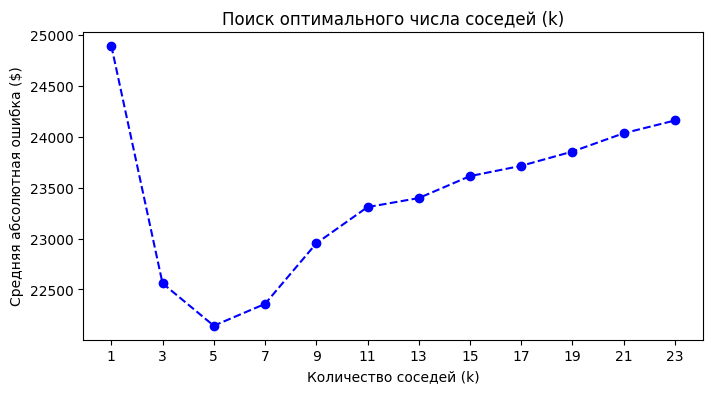

In [6]:
errors = []
k_values = range(1, 25, 2)

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    errors.append(mean_absolute_error(y_test, y_pred))

plt.figure(figsize=(8, 4))
plt.plot(k_values, errors, marker="o", linestyle="dashed", color="blue")
plt.title("Поиск оптимального числа соседей (k)")
plt.xlabel("Количество соседей (k)")
plt.ylabel("Средняя абсолютная ошибка ($)")
plt.xticks(k_values)
plt.show()

# 6. Поиск оптимального k

Перебираются нечётные k от 1 до 25, для каждого считается MAE на тесте и строится график ошибки. Малые k дают переобучение, большие - недообучение. Оптимум найден в средней зоне, где MAE минимальна.

In [7]:
best_k = 5

knn_euclidean = KNeighborsRegressor(n_neighbors=best_k, p=2)
knn_euclidean.fit(X_train, y_train)
y_pred_euc = knn_euclidean.predict(X_test)

knn_manhattan = KNeighborsRegressor(n_neighbors=best_k, p=1)
knn_manhattan.fit(X_train, y_train)
y_pred_man = knn_manhattan.predict(X_test)

print("=== Сравнение метрик расстояния ===")
print(f"Евклидово расстояние (p=2): MAE = ${mean_absolute_error(y_test, y_pred_euc):.2f} | R2 = {r2_score(y_test, y_pred_euc):.2f}")
print(f"Манхэттенское расстояние (p=1): MAE = ${mean_absolute_error(y_test, y_pred_man):.2f} | R2 = {r2_score(y_test, y_pred_man):.2f}")

=== Сравнение метрик расстояния ===
Евклидово расстояние (p=2): MAE = $22144.03 | R2 = 0.10
Манхэттенское расстояние (p=1): MAE = $22248.23 | R2 = 0.10


**Вывод:** при малых k - переобучение (высокая дисперсия), при больших - недообучение (высокое смещение). Оптимум - в средней зоне, где MAE минимально.

# 7. Сравнение метрик расстояния

При оптимальном k обучены две модели: с Евклидовым (p=2) и Манхэттенским (p=1) расстоянием. Результаты почти совпали: MAE ~ 22 144 и 22 248, R² = 0,10 в обоих случаях. Это говорит о симметричной структуре данных без выраженных выбросов.

In [8]:
gamma_values = np.logspace(-4, 0, 30)

best_gamma = 0
best_r2 = -float("inf")
best_mae = float("inf")

for g in gamma_values:
    weights = rbf_kernel(X_test, X_train, gamma=g)
    weights_normalized = weights / weights.sum(axis=1, keepdims=True)

    y_pred_nw = np.dot(weights_normalized, y_train.values)

    r2 = r2_score(y_test, y_pred_nw)
    mae = mean_absolute_error(y_test, y_pred_nw)

    if r2 > best_r2:
        best_r2 = r2
        best_mae = mae
        best_gamma = g

print("=== Итоги оптимизации ядерной регрессии ===")
print(f"Оптимальный gamma: {best_gamma:.4f}")
print(f"Лучшее R2: {best_r2:.2f}")
print(f"Лучшее MAE: ${best_mae:.2f}")


=== Итоги оптимизации ядерной регрессии ===
Оптимальный gamma: 1.0000
Лучшее R2: 0.04
Лучшее MAE: $26976.37


**Вывод:** если метрики близки - структура данных симметрична; если побеждает p=1 - в данных есть выбросы, к которым Манхэттен устойчивее.

# 8. Ядерная регрессия Надарая-Ватсона

Реализована регрессия с Гауссовым ядром (rbf_kernel). Гиперпараметр gamma перебирался в лог-шкале. Лучший результат: gamma = 1,0, R² ~ 0,04, MAE ~ 26 976 $. Оптимальная gamma - компромисс между слишком широким окном (сглаживает различия) и слишком узким (переобучение)

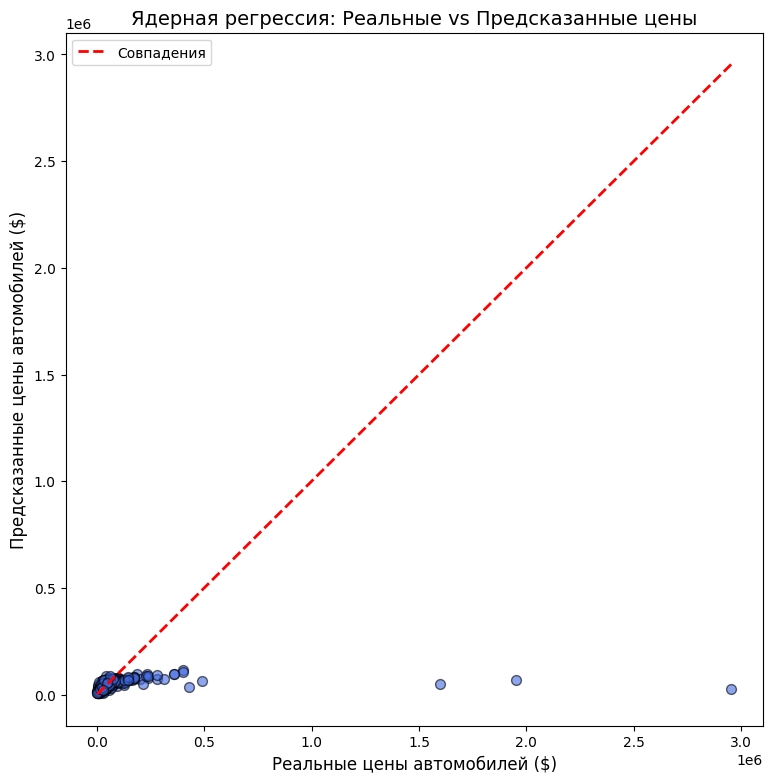

In [9]:
plt.figure(figsize=(9, 9))

plt.scatter(y_test, y_pred_nw, alpha=0.6, color="royalblue", edgecolor="k", s=50)

max_val = max(y_test.max(), y_pred_nw.max())
min_val = min(y_test.min(), y_pred_nw.min())

plt.plot(
    [min_val, max_val], [min_val, max_val], "r--", lw=2, label="Совпадения"
)

plt.title("Ядерная регрессия: Реальные vs Предсказанные цены", fontsize=14)
plt.xlabel("Реальные цены автомобилей ($)", fontsize=12)
plt.ylabel("Предсказанные цены автомобилей ($)", fontsize=12)
plt.legend()
plt.show()

**Вывод:** Построен Scatter-график «реальные vs предсказанные цены» с идеальной диагональю. Разброс точек вокруг диагонали показывает, что модель плохо улавливает дорогие автомобили и объясняет лишь малую долю разброса цен.

# 9. Финальный вывод

Из двух моделей лучше себя показала *kNN* (R² ~ 0.10, MAE ~ 22 144), ядерная регрессия оказалась слабее (R² ~ 0.04, MAE ~ 26 976 $). Низкий R² объясняется тем, что при подготовке данных были удалены признаки engine и model, сильно влияющие на цену. Для практического применения модель нужно доработать: вернуть эти признаки и корректно их закодировать.